In [1]:
import os
import pandas as pd
import seaborn as sns
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib import rc_context

/home/wu/mambaforge/envs/AutoExtract/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/wu/mambaforge/envs/AutoExtract/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/wu/mambaforge/envs/AutoExtract/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/wu/mambaforge/envs/AutoExtract/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/wu/mambaforge/envs/AutoExtract/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarn

In [2]:
def extract_matrix_data(text):
    """
    Extract structured data from performance matrix text.
    
    Parameters:
    text (str): Text containing ARI and similarity metrics
    
    Returns:
    dict: Dictionary with extracted metrics
    """
    lines = text.strip().split('\n')
    
    # Initialize result dictionary
    result = {
        'ari': {},
        'similarity': {},
        'group_level_similarity': {}
    }
    
    for line in lines:
        line = line.strip()
        
        # Extract ARI values
        if line.startswith('ARI for '):
            parts = line.split(': ')
            if len(parts) == 2:
                method = parts[0].replace('ARI for ', '')
                value = float(parts[1])
                result['ari'][method] = value
        
        # Extract Similarity values (non-group level)
        elif line.startswith('Similarity key: ') and 'Group-level' not in line:
            parts = line.split(', ')
            if len(parts) == 2:
                key = parts[0].replace('Similarity key: ', '')
                mean_part = parts[1]
                mean_value = float(mean_part.replace('Mean: ', ''))
                result['similarity'][key] = mean_value
        
        # Extract Group-level Similarity values
        elif line.startswith('Group-level Similarity key: '):
            parts = line.split(', ')
            if len(parts) == 2:
                key = parts[0].replace('Group-level Similarity key: ', '')
                mean_part = parts[1]
                mean_value = float(mean_part.replace('Mean: ', ''))
                result['group_level_similarity'][key] = mean_value
    
    return result

In [3]:
df_list = []
dir_ = '/home/wu/datb1/AutoExtractSingleCell/01.benchmark_datasets'
for sample in os.listdir(dir_):
    if sample in ['sample1', 'sample3', 'sample4', 'sample5']:
        res = os.path.join(dir_, sample, f'{sample}_claude_35_with_gptcelltype_metrics.txt')
        with open(res) as f:
            text = f.read()
        metrics = extract_matrix_data(text)
        df = pd.DataFrame(metrics['group_level_similarity'], index=[sample])
        df['sample'] = sample
        df['with_met'] = True
        df_list.append(df)
        
        res_no_met = os.path.join(dir_, sample, f'{sample}_claude_35_with_gptcelltypeno_met_metrics.txt')
        with open(res_no_met) as f:
            text_no_met = f.read()
        metrics_no_met = extract_matrix_data(text_no_met)
        df_no_met = pd.DataFrame(metrics_no_met['group_level_similarity'], index=[f'{sample}_no_met'])
        df_no_met['sample'] = sample
        df_no_met['with_met'] = False
        df_list.append(df_no_met)
        
df = pd.concat(df_list)

In [4]:
df = df.melt(id_vars=['sample', 'with_met'], var_name='metric', value_name='value')
df.rename(columns={'sample': 'Sample', 'with_met': 'With Methods', 'metric': 'Metric', 'value': 'Group-level Accuracy'}, inplace=True)

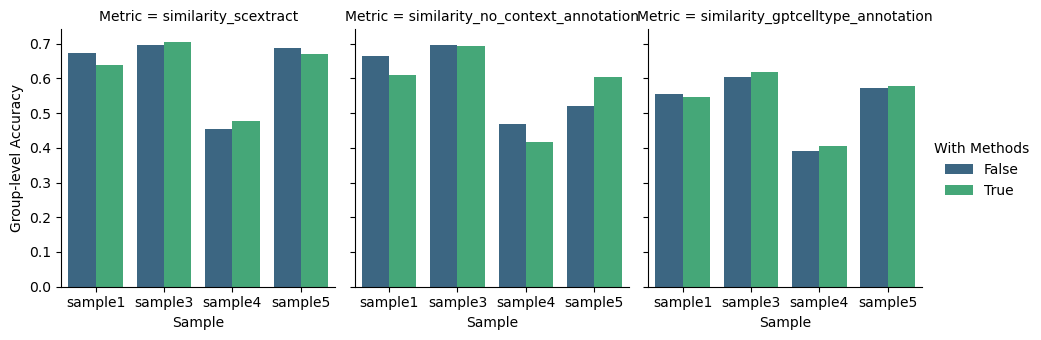

In [5]:
with rc_context({'figure.figsize': (6, 3)}):
    sns.catplot(data=df, x='Sample', y='Group-level Accuracy', hue='With Methods', col='Metric', kind='bar', height=3.5, aspect=0.9,
                order=['sample1', 'sample3', 'sample4', 'sample5'], palette='viridis')
    plt.savefig('/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/article_quality/with_met_vs_no_met_group_level_accuracy.pdf', bbox_inches='tight')